In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [55]:
cols = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
        'marital_status', 'occupation', 'relationship', 'race', 'sex',
        'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

In [56]:
df = pd.read_csv('adult.data.csv', header=None, names=cols,
                 na_values=[' ?', '?'], skipinitialspace=True)
print("Dataset loaded")
print("Shape:", df.shape)
print()
df.head()

Dataset loaded
Shape: (32561, 15)



,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [57]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object


In [58]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [59]:
print("\n--- Basic Stats ---")
print(df.describe())


--- Basic Stats ---
                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [60]:
print("\nDuplicates:", df.duplicated().sum())


Duplicates: 24


Text(0.5, 1.0, 'Missing Values Heatmap')

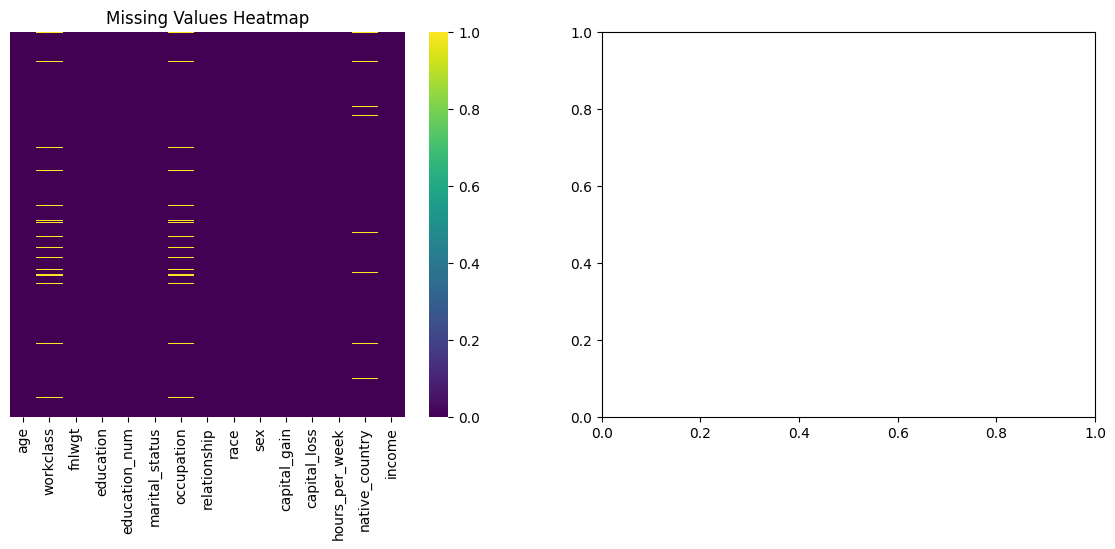

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Values Heatmap')

In [62]:
print(f"\nRows before removing duplicates: {len(df)}")
df = df.drop_duplicates()
print(f"Rows after  removing duplicates: {len(df)}")


Rows before removing duplicates: 32561
Rows after  removing duplicates: 32537


In [63]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
 
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Filled {col} with median")
 
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"Filled {col} with mode -> {df[col].mode()[0]}")
 
print("\nMissing after fill:", df.isnull().sum().sum())

Filled workclass with mode -> Private
Filled occupation with mode -> Prof-specialty
Filled native_country with mode -> United-States

Missing after fill: 0


In [64]:
for col in cat_cols:
    df[col] = df[col].str.strip()
 
# income column sometimes has a period at end in test sets
df['income'] = df['income'].str.replace('.', '', regex=False)
 
print("\nIncome values:", df['income'].unique())
print("Sex values:", df['sex'].unique())


Income values: ['<=50K' '>50K']
Sex values: ['Male' 'Female']


In [65]:
check_cols = ['age', 'hours_per_week']
 
print("\n--- Outlier Summary ---")
for col in check_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"  {col}: {outliers} outliers capped | bounds [{lower:.1f}, {upper:.1f}]")


--- Outlier Summary ---
  age: 142 outliers capped | bounds [-2.0, 78.0]
  hours_per_week: 9002 outliers capped | bounds [32.5, 52.5]


In [66]:
df_raw = pd.read_csv('adult.data.csv', header=None, names=cols,
                     na_values=[' ?', '?'], skipinitialspace=True)
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Outliers Before vs After Capping', fontsize=14, fontweight='bold')
 
plot_cols = ['age', 'hours_per_week']
for i, col in enumerate(plot_cols):
    axes[i, 0].boxplot(df_raw[col].dropna(),
                       patch_artist=True,
                       boxprops=dict(facecolor='salmon'))
    axes[i, 0].set_title(f'{col} - Before')
 
    axes[i, 1].boxplot(df[col].dropna(),
                       patch_artist=True,
                       boxprops=dict(facecolor='lightgreen'))
    axes[i, 1].set_title(f'{col} - After')
 
plt.tight_layout()
plt.savefig('02_outliers.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nSaved: 01_outliers.png")


Saved: 01_outliers.png


In [67]:
df['age'] = df['age'].clip(17, 90)
df['hours_per_week'] = df['hours_per_week'].clip(1, 99)
df['hours_per_week'] = df['hours_per_week'].astype(int)
print(f"\nAge range: {df['age'].min()} - {df['age'].max()}")
print(f"Hours range: {df['hours_per_week'].min()} - {df['hours_per_week'].max()}")


Age range: 17 - 78
Hours range: 32 - 52


In [68]:
df['age_group'] = pd.cut(df['age'],
                          bins=[17, 25, 35, 50, 90],
                          labels=['Youth', 'Young Adult', 'Middle Age', 'Senior'],
                          include_lowest=True)

In [69]:
df['capital_net'] = df['capital_gain'] - df['capital_loss']
 
# converting income to 0/1 for analysis
df['is_high_earner'] = (df['income'] == '>50K').astype(int)
 
print("\nNew columns added: age_group, capital_net, is_high_earner")
print(df['age_group'].value_counts())
print(f"\nHigh earners: {df['is_high_earner'].sum():,}")
print(f"Low earners : {(df['is_high_earner'] == 0).sum():,}")


New columns added: age_group, capital_net, is_high_earner
age_group
Middle Age     11168
Young Adult     8510
Senior          6459
Youth           6400
Name: count, dtype: int64

High earners: 7,839
Low earners : 24,698


In [70]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(df['age'].mean(), color='red', linestyle='--',
           label=f"Mean = {df['age'].mean():.1f}")
ax.axvline(df['age'].median(), color='orange', linestyle='--',
           label=f"Median = {df['age'].median():.1f}")
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('03_age_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nSaved: 03_age_distribution.png")


Saved: 03_age_distribution.png


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
income_counts = df['income'].value_counts()
bars = axes[0].bar(income_counts.index, income_counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.4)
axes[0].set_title('Income Distribution')
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'{int(bar.get_height()):,}', ha='center', fontweight='bold')
 
axes[1].pie(income_counts.values, labels=income_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Income Split (%)')
 
plt.tight_layout()
plt.savefig('04_income.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: 04_income.png")

Saved: 04_income.png


In [72]:
edu_income = df.groupby('education')['is_high_earner'].mean().sort_values(ascending=False)
 
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(edu_income.index, edu_income.values * 100,
       color='mediumpurple', edgecolor='black', alpha=0.85)
ax.set_title('% High Earners by Education Level')
ax.set_xlabel('Education')
ax.set_ylabel('% Earning >50K')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('05_education_vs_income.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: 05_education_vs_income.png")

Saved: 05_education_vs_income.png


In [73]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['hours_per_week'], bins=25, color='darkorange', edgecolor='black', alpha=0.8)
ax.axvline(40, color='red', linestyle='--', label='Standard 40hrs')
ax.axvline(df['hours_per_week'].mean(), color='blue', linestyle='--',
           label=f"Mean = {df['hours_per_week'].mean():.1f}")
ax.set_title('Hours Per Week Distribution')
ax.set_xlabel('Hours/Week')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('06_hours_per_week.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: 06_hours_per_week.png")

Saved: 06_hours_per_week.png


In [74]:
workclass_income = pd.crosstab(df['workclass'], df['income'])
 
fig, ax = plt.subplots(figsize=(12, 6))
workclass_income.plot(kind='bar', ax=ax,
                      color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
ax.set_title('Work Class vs Income')
ax.set_xlabel('Work Class')
ax.set_ylabel('Count')
ax.legend(title='Income')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('07_workclass_vs_income.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: 07_workclass_vs_income.png")

Saved: 07_workclass_vs_income.png


In [75]:
age_income = pd.crosstab(df['age_group'], df['income'], normalize='index') * 100
 
fig, ax = plt.subplots(figsize=(12, 5))
age_income.plot(kind='bar', ax=ax,
                color=['#27ae60', '#c0392b'], edgecolor='black', alpha=0.85)
ax.set_title('Income by Age Group (%)')
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage')
ax.legend(title='Income')
ax.tick_params(axis='x', rotation=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('08_age_group_vs_income.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: 08_age_group_vs_income.png")

Saved: 08_age_group_vs_income.png


In [76]:
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()
 
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('09_correlation.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: 09_correlation.png")
 
print("\nTop features correlated with income:")
print(corr['is_high_earner'].drop('is_high_earner').sort_values(key=abs, ascending=False))

Saved: 09_correlation.png

Top features correlated with income:
education_num     0.335272
hours_per_week    0.271897
age               0.235830
capital_gain      0.223336
capital_net       0.214437
capital_loss      0.150501
fnlwgt           -0.009502
Name: is_high_earner, dtype: float64


In [77]:
df_raw = pd.read_csv('adult.data.csv', header=None, names=cols,
                     na_values=[' ?', '?'], skipinitialspace=True)
 
print("\n========== CLEANING SUMMARY ==========")
print(f"Original shape  : {df_raw.shape}")
print(f"Cleaned shape   : {df.shape}")
print(f"Duplicates removed : {df_raw.duplicated().sum()}")
print(f"Missing before  : {df_raw.isnull().sum().sum()}")
print(f"Missing after   : {df.isnull().sum().sum()}")
print(f"New columns     : age_group, capital_net, is_high_earner")
print("======================================")
 
print("\nSample of cleaned data:")
print(df[['age', 'age_group', 'workclass', 'education',
          'occupation', 'income', 'is_high_earner']].head(10))


========== CLEANING SUMMARY ==========
Original shape  : (32561, 15)
Cleaned shape   : (32537, 18)
Duplicates removed : 24
Missing before  : 4262
Missing after   : 0
New columns     : age_group, capital_net, is_high_earner

Sample of cleaned data:
   age    age_group         workclass  education         occupation income  \
0   39   Middle Age         State-gov  Bachelors       Adm-clerical  <=50K   
1   50   Middle Age  Self-emp-not-inc  Bachelors    Exec-managerial  <=50K   
2   38   Middle Age           Private    HS-grad  Handlers-cleaners  <=50K   
3   53       Senior           Private       11th  Handlers-cleaners  <=50K   
4   28  Young Adult           Private  Bachelors     Prof-specialty  <=50K   
5   37   Middle Age           Private    Masters    Exec-managerial  <=50K   
6   49   Middle Age           Private        9th      Other-service  <=50K   
7   52       Senior  Self-emp-not-inc    HS-grad    Exec-managerial   >50K   
8   31  Young Adult           Private    Masters 

In [78]:
before = len(df)
df = df.drop_duplicates()
print(f"Final duplicate check: removed {before - len(df)} rows")

Final duplicate check: removed 16 rows


In [79]:
df.to_csv('adult_income_cleaned.csv', index=False)
print("\nSaved cleaned dataset: adult_income_cleaned.csv")
print("Done!")



Saved cleaned dataset: adult_income_cleaned.csv
Done!
